# 1. Preparation

In [10]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import sys
sys.path.append('../../../')
from utilities import print_exams

class DNADataset(Dataset):
    def __init__(self, DataFrame):
        self.sequence = (DataFrame['serumHA_DNA'] + '<eos>' + DataFrame['virusHA_DNA'] + \
            '<eos>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat']).tolist()
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequence[idx], self.labels[idx]

class AADataset(Dataset):
    def __init__(self, DataFrame):
        self.sequence = (DataFrame['seq_a'] + '<eos>' + DataFrame['seq_c'] + \
                         '<eos>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat']).tolist()
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequence[idx], self.labels[idx]

In [ ]:
test_df = pd.read_csv('./test_data.csv')
DNA_test_dataset = DNADataset(test_df)
AA_test_dataset = AADataset(test_df)
DNA_test_loader = DataLoader(DNA_test_dataset, batch_size=128, shuffle=False)
AA_test_loader = DataLoader(AA_test_dataset, batch_size=128, shuffle=False)

In [22]:
DNA_model = torch.load(f='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.1_DNA_model/2025-10-24_22-42-28.pth',
                       weights_only=False)
                
AA_model = torch.load(f='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.1_AA_model/2025-10-21_21-54-19.pth',
                      weights_only=False)
device = DNA_model.device

# 2. Crick test

## 2.1 DNA model

In [ ]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_DNA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []

DNA_model.eval()
for batch_seq, batch_label in DNA_test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    
    with torch.no_grad():
        outputs = DNA_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

  
DNA_Crick_df = test_df.copy()
DNA_Crick_df['prediction'] = prediction_ls_final

DNA_Crick_H1N1 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H1N1']
DNA_Crick_H3N2 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(DNA_Crick_H1N1['HI_Dist'], DNA_Crick_H1N1['prediction'])
## H3N2
print_exams(DNA_Crick_H3N2['HI_Dist'], DNA_Crick_H3N2['prediction'])

KeyError: 'serumType'

In [15]:
DNA_Crick_H1N1 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H1N1']
DNA_Crick_H3N2 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(DNA_Crick_H1N1['label'], DNA_Crick_H1N1['prediction'])
## H3N2
print_exams(DNA_Crick_H3N2['label'], DNA_Crick_H3N2['prediction'])

MAE: 0.70929
MSE: 0.86151
pearson correlation: 0.88296
spearman correlation: 0.84983
R2_score: 0.72957
MAE: 0.67969
MSE: 0.77107
pearson correlation: 0.86276
spearman correlation: 0.69830
R2_score: 0.65928
MAE: 0.74360
MSE: 0.96633
pearson correlation: 0.84550
spearman correlation: 0.85030
R2_score: 0.62138


(0.7435954111265429,
 0.9663284484543166,
 PearsonRResult(statistic=0.8454975234193507, pvalue=0.0),
 SignificanceResult(statistic=0.8503049636712874, pvalue=0.0),
 0.6213780456120208)

## 2.2 AA model

In [ ]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
AA_model.eval()
for batch_seq, batch_label in AA_test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    
    with torch.no_grad():
        outputs = AA_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

AA_Crick_df = test_df.copy()
AA_Crick_df['prediction'] = prediction_ls_final

AA_Crick_H1N1 = AA_Crick_df[AA_Crick_df['Type'] == 'H1N1']
AA_Crick_H3N2 = AA_Crick_df[AA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(AA_Crick_H1N1['label'], AA_Crick_H1N1['prediction'])
## H3N2
print_exams(AA_Crick_H3N2['label'], AA_Crick_H3N2['prediction'])

MAE: 0.69890
MSE: 0.82422
pearson correlation: 0.88823
spearman correlation: 0.85342
R2_score: 0.74463
MAE: 0.67515
MSE: 0.75608
pearson correlation: 0.86632
spearman correlation: 0.69732
R2_score: 0.68290
MAE: 0.72643
MSE: 0.90318
pearson correlation: 0.85520
spearman correlation: 0.85969
R2_score: 0.65473


(0.7264283619216084,
 0.903180035554183,
 PearsonRResult(statistic=0.8552020606660645, pvalue=0.0),
 SignificanceResult(statistic=0.859693552394419, pvalue=0.0),
 0.6547320089241125)

# 3. CDC test

In [12]:
import pandas as pd

CDC_data = pd.read_csv('../../../data/processed/0.1_Final_df-CDC.csv')

In [13]:
## select required columns
DNA_data_filt1 = CDC_data[['serumName','virusName','serumHA_DNA','virusHA_DNA','serumPassCat','virusPassCat',
                            'serumType','HI_Dist']].copy()
## remove duplicated row and mean HI_Dist
DNA_data_filt2 = DNA_data_filt1.groupby(['serumHA_DNA', 'virusHA_DNA', 'serumPassCat', 'virusPassCat']) \
        .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'HI_Dist': 'mean'}) \
        .reset_index()[['serumName', 'virusName', 'serumHA_DNA', 'virusHA_DNA',
                        'serumPassCat', 'virusPassCat', 'serumType', 'HI_Dist']]
## remove PassCat = 'BOTH'
DNA_data_filt3 = DNA_data_filt2[(DNA_data_filt2['serumPassCat'] != 'BOTH') &
                                (DNA_data_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
## replace PassCat to special token
DNA_data_filt4 = DNA_data_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                         'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

## select required columns
AA_data_filt1 = CDC_data[['serumName','virusName','serumHA_AA','virusHA_AA','serumPassCat','virusPassCat',
                          'serumType','HI_Dist']].copy()
## remove duplicated row and mean HI_Dist
AA_data_filt2 = AA_data_filt1.groupby(['serumHA_AA', 'virusHA_AA', 'serumPassCat', 'virusPassCat']) \
        .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'HI_Dist': 'mean'}) \
        .reset_index()[['serumName', 'virusName', 'serumHA_AA', 'virusHA_AA',
                        'serumPassCat', 'virusPassCat', 'serumType', 'HI_Dist']]
## remove PassCat = 'BOTH'
AA_data_filt3 = AA_data_filt2[(AA_data_filt2['serumPassCat'] != 'BOTH') &
                              (AA_data_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
## replace PassCat to special token
AA_data_filt4 = AA_data_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                       'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

In [14]:
DNA_CDC_dataset = DNADataset(DNA_data_filt4)
AA_CDC_dataset = AADataset(AA_data_filt4)

DNA_CDC_loader = DataLoader(DNA_CDC_dataset, batch_size=128, shuffle=False)
AA_CDC_loader = DataLoader(AA_CDC_dataset, batch_size=128, shuffle=False)

In [16]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_DNA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
with torch.no_grad():
    DNA_model.eval()
    for batch_seq, batch_label in DNA_CDC_loader:
        batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
        batch_input = batch_input.to(device)
        batch_label = batch_label.to(device)

        outputs = DNA_model(**batch_input, labels=batch_label)
        logits = outputs.logits
        loss = outputs.loss

        logits_ls.append(logits)
        loss_ls_valid.append(loss.item())
        prediction_ls += logits.tolist()
        prediction_ls_final = []
        for sublist in prediction_ls:
            for element in sublist:
                prediction_ls_final.append(element)
        reference_ls += batch_label.tolist()


DNA_CDC_df = DNA_data_filt4.copy()
DNA_CDC_df['prediction'] = prediction_ls_final
DNA_CDC_H1N1 = DNA_CDC_df[DNA_CDC_df['serumType'] == 'H1N1']
DNA_CDC_H3N2 = DNA_CDC_df[DNA_CDC_df['serumType'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(DNA_CDC_H1N1['HI_Dist'], DNA_CDC_H1N1['prediction'])
## H3N2
print_exams(DNA_CDC_H3N2['HI_Dist'], DNA_CDC_H3N2['prediction'])

MAE:  1.4141176670994222
MSE:  3.3922873589071343
pearson correlation:  PearsonRResult(statistic=0.5405774304102625, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.5462790928761642, pvalue=0.0)
R2_score:  -0.3079981049423839
MAE:  0.9124415716902156
MSE:  1.3916376506769008
pearson correlation:  PearsonRResult(statistic=0.8446539382704435, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.5626899688971582, pvalue=0.0)
R2_score:  0.6686984314591777
MAE:  1.6860885905366516
MSE:  4.476888664953443
pearson correlation:  PearsonRResult(statistic=0.135703464732633, pvalue=1.2309455368254387e-31)
spearman correlation:  SignificanceResult(statistic=0.12965366858375083, pvalue=5.304328027984386e-29)
R2_score:  -2.4534570611316506


In [ ]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
with torch.no_grad():
    AA_model.eval()
    for batch_seq, batch_label in AA_CDC_loader:
        batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
        batch_input = batch_input.to(device)
        batch_label = batch_label.to(device)

        outputs = AA_model(**batch_input, labels=batch_label)
        logits = outputs.logits
        loss = outputs.loss

        logits_ls.append(logits)
        loss_ls_valid.append(loss.item())
        prediction_ls += logits.tolist()
        prediction_ls_final = []
        for sublist in prediction_ls:
            for element in sublist:
                prediction_ls_final.append(element)
        reference_ls += batch_label.tolist()

AA_CDC_df = AA_data_filt4.copy()
AA_CDC_df['prediction'] = prediction_ls_final
AA_CDC_H1N1 = AA_CDC_df[AA_CDC_df['serumType'] == 'H1N1']
AA_CDC_H3N2 = AA_CDC_df[AA_CDC_df['serumType'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(AA_CDC_H1N1['HI_Dist'], AA_CDC_H1N1['prediction'])
## H3N2
print_exams(AA_CDC_H3N2['HI_Dist'], AA_CDC_H3N2['prediction'])

MAE:  1.1964716568373455
MSE:  2.4372964004222903
pearson correlation:  PearsonRResult(statistic=0.6846096085117908, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.6949841455531214, pvalue=0.0)
R2_score:  0.13447664227866396
MAE:  0.8423420983878076
MSE:  1.254618647887769
pearson correlation:  PearsonRResult(statistic=0.8576239950647642, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.5674634198545708, pvalue=4.55700560818628e-249)
R2_score:  0.6266891089695394
MAE:  1.4250582630504207
MSE:  3.200701451295889
pearson correlation:  PearsonRResult(statistic=0.4255186191245489, pvalue=8.12347636422607e-199)
spearman correlation:  SignificanceResult(statistic=0.4271181772858001, pvalue=1.8543238561694392e-200)
R2_score:  -0.9191639197012393


: 

# 4. Future test

In [ ]:
test_df = pd.read_csv('../../../../data/MEGA_data/Crick_41_with_DNA.csv')
DNA_test_dataset = DNADataset(test_df)
AA_test_dataset = AADataset(test_df)
DNA_test_loader = DataLoader(DNA_test_dataset, batch_size=128, shuffle=False)
AA_test_loader = DataLoader(AA_test_dataset, batch_size=128, shuffle=False)

In [8]:
DNA_model = torch.load(f='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.1_DNA_model/2025-10-24_22-42-28.pth',
                       weights_only=False)
                
AA_model = torch.load(f='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.1_AA_model/2025-10-21_21-54-19.pth',
                      weights_only=False)
device = DNA_model.device

In [13]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_DNA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []

DNA_model.eval()
for batch_seq, batch_label in DNA_test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    
    with torch.no_grad():
        outputs = DNA_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

  
DNA_Crick_df = test_df.copy()
DNA_Crick_df['prediction'] = prediction_ls_final

DNA_Crick_H1N1 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H1N1']
DNA_Crick_H3N2 = DNA_Crick_df[DNA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(DNA_Crick_H1N1['label'], DNA_Crick_H1N1['prediction'])
## H3N2
print_exams(DNA_Crick_H3N2['label'], DNA_Crick_H3N2['prediction'])

MAE: 0.76865
MSE: 0.89290
pearson correlation: 0.64381
spearman correlation: 0.65893
R2_score: -0.30842
MAE: 0.72998
MSE: 0.79066
pearson correlation: 0.45547
spearman correlation: 0.50934
R2_score: -1.75065
MAE: 0.81961
MSE: 1.02765
pearson correlation: 0.31029
spearman correlation: 0.20044
R2_score: -1.37202


(0.8196063046135368,
 1.0276523976951983,
 PearsonRResult(statistic=0.3102861914508085, pvalue=1.332676062097015e-24),
 SignificanceResult(statistic=0.20044418717193294, pvalue=7.202729123618775e-11),
 -1.3720241724524)

In [14]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
AA_model.eval()
for batch_seq, batch_label in AA_test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    
    with torch.no_grad():
        outputs = AA_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

AA_Crick_df = test_df.copy()
AA_Crick_df['prediction'] = prediction_ls_final

AA_Crick_H1N1 = AA_Crick_df[AA_Crick_df['Type'] == 'H1N1']
AA_Crick_H3N2 = AA_Crick_df[AA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(AA_Crick_H1N1['label'], AA_Crick_H1N1['prediction'])
## H3N2
print_exams(AA_Crick_H3N2['label'], AA_Crick_H3N2['prediction'])

MAE: 0.75578
MSE: 0.91008
pearson correlation: 0.66406
spearman correlation: 0.66804
R2_score: 0.24345
MAE: 0.72133
MSE: 0.81495
pearson correlation: 0.37505
spearman correlation: 0.41822
R2_score: -0.77518
MAE: 0.80117
MSE: 1.03545
pearson correlation: 0.47301
spearman correlation: 0.49293
R2_score: -0.15531


(0.8011729661022893,
 1.0354458095484997,
 PearsonRResult(statistic=0.47301035899622573, pvalue=5.519841028768764e-59),
 SignificanceResult(statistic=0.4929271880562811, pvalue=1.198163402842232e-64),
 -0.1553085049166516)

# 4. Visualization

In [130]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

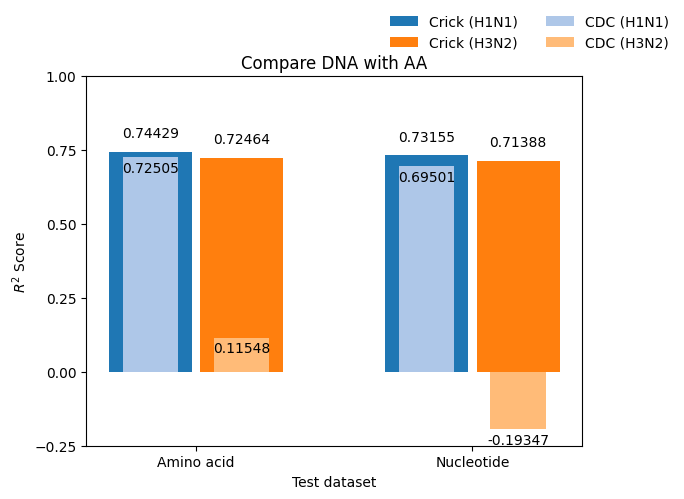

In [133]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
samples = ['Amino acid', 'Nucleotide']
datasets = ['Crick', 'CDC']
# AA and DNA use R2 score to evaluate the model

H1_data = {
    'Crick': [0.74429, 0.73155],
    'CDC': [0.72505, 0.69501]
}
H3_data = {
    'Crick': [0.72464, 0.71388],
    'CDC': [0.11548, -0.19347]
}

# 设置柱状图的位置
x = np.arange(len(samples))

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制每个波长的柱状图
colors_H1 = ['#1f77b4', '#aec7e8']  # 深蓝色和浅蓝色
colors_H3 = ['#ff7f0e', '#ffbb78']  # 橙色和浅橙色
widths = [0.3, 0.2]  # 设置每个柱子的宽度
dataset_drift = [0.05, -0.05]
for i, dataset in enumerate(datasets):
    ax.bar(x - widths[0]*1.1/2, H1_data[dataset], width=widths[i], label=dataset + ' (H1N1)', color=colors_H1[i], capsize=5)
    ax.text(x[0] - widths[0]*1.1/2, H1_data[dataset][0] + dataset_drift[i], str(H1_data[dataset][0]), ha='center')
    ax.text(x[1] - widths[0]*1.1/2, H1_data[dataset][1] + dataset_drift[i], str(H1_data[dataset][1]), ha='center')
    ax.bar(x + widths[0]*1.1/2, H3_data[dataset], width=widths[i], label=dataset + ' (H3N2)', color=colors_H3[i], capsize=5)
    ax.text(x[0] + widths[0]*1.1/2, H3_data[dataset][0] + dataset_drift[i], str(H3_data[dataset][0]), ha='center')
    ax.text(x[1] + widths[0]*1.1/2, H3_data[dataset][1] + dataset_drift[i], str(H3_data[dataset][1]), ha='center')



# 设置标签和标题
ax.set_xlabel('Test dataset')
ax.set_ylabel(r'$R^2$ Score')
ax.set_title('Compare DNA with AA')
ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_yticks(np.arange(-0.25, 1.25, 0.25))
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False, ncol=2)


# 显示图形
plt.savefig('1.2_test.svg', dpi=300, bbox_inches='tight')

In [6]:
AA_H1N1_result = print_exams(AA_Crick_df.loc[AA_Crick_df['serumType'] == 'H1N1','prediction'], 
AA_Crick_df.loc[AA_Crick_df['serumType'] == 'H1N1', 'HI_Dist'], print_result=False)
AA_H3N2_result = print_exams(AA_Crick_df.loc[AA_Crick_df['serumType'] == 'H3N2','prediction'], 
AA_Crick_df.loc[AA_Crick_df['serumType'] == 'H3N2', 'HI_Dist'], print_result=False)
DNA_H1N1_result = print_exams(DNA_Crick_df.loc[DNA_Crick_df['serumType'] == 'H1N1', 'prediction'], 
DNA_Crick_df.loc[DNA_Crick_df['serumType'] == 'H1N1', 'HI_Dist'], print_result=False)
DNA_H3N2_result = print_exams(DNA_Crick_df.loc[DNA_Crick_df['serumType'] == 'H3N2', 'prediction'], 
DNA_Crick_df.loc[DNA_Crick_df['serumType'] == 'H3N2', 'HI_Dist'], print_result=False)

In [15]:
df = pd.DataFrame({
    'model': ['AA', 'DNA'],
    'H1_MAE': [AA_H1N1_result[0], DNA_H1N1_result[0]],
    'H1_Pearson': [AA_H1N1_result[2][0], DNA_H1N1_result[2][0]],
    'H3_MAE': [AA_H3N2_result[0], DNA_H3N2_result[0]],
    'H3_Pearson': [AA_H3N2_result[2][0], DNA_H3N2_result[2][0]]
})

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 示例数据
df = pd.DataFrame({
    'model': ['AA', 'DNA'],
    'H1_MAE': [AA_H1N1_result[0], DNA_H1N1_result[0]],
    'H3_MAE': [AA_H3N2_result[0], DNA_H3N2_result[0]],
    'H1_Pearson': [AA_H1N1_result[2][0], DNA_H1N1_result[2][0]],
    'H3_Pearson': [AA_H3N2_result[2][0], DNA_H3N2_result[2][0]]
})

# X 轴位置
x = np.arange(len(df['model']))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))

# --- 并列两根 MAE 柱 ---
bar1 = ax.bar(x - width/2, df['H1_MAE'], width, label='MAE-H1', color="#CBDEEE")
bar2 = ax.bar(x + width/2, df['H3_MAE'], width, label='MAE-H3', color="#EBE6B5")

# 美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_ylabel('MAE', fontsize=13)
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(df['model'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# --- 折线图，两条 ---
ax2 = ax.twinx()

# 对齐到柱中心的 x 坐标
h1_x = x - width/2
h3_x = x + width/2

# H1 Pearson
ax2.plot(h1_x, df['H1_Pearson'], label='Pearson-H1',
         marker='o', linestyle='-', linewidth=1.5)

# H3 Pearson
ax2.plot(h3_x, df['H3_Pearson'], label='Pearson-H3',
         marker='s', linestyle='--', linewidth=1.5)

ax2.set_ylabel("Pearson", fontsize=13, color='black')
ax2.tick_params(axis='y', labelsize=12, colors='black')
ax2.set_ylim(0, 1)

# 合并 legend（主轴 + 副轴）
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          frameon=False, fontsize=11, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.18))


plt.tight_layout()
plt.savefig("Figure_S1a.svg", dpi=300, transparent=True)

NameError: name 'AA_H1N1_result' is not defined

: 

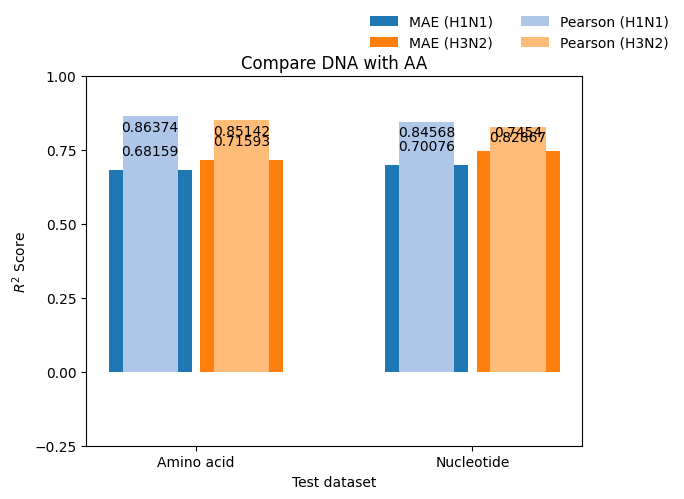

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
samples = ['Amino acid', 'Nucleotide']
datasets = ['MAE', 'Pearson']
# AA and DNA use R2 score to evaluate the model

H1_data = {
    'MAE': [round(AA_H1N1_result[0], 5), round(DNA_H1N1_result[0], 5)],
    'Pearson': [round(AA_H1N1_result[2][0], 5), round(DNA_H1N1_result[2][0], 5)]
}
H3_data = {
    'MAE': [round(AA_H3N2_result[0], 5), round(DNA_H3N2_result[0], 5)],
    'Pearson': [round(AA_H3N2_result[2][0], 5), round(DNA_H3N2_result[2][0], 5)]
}

# 设置柱状图的位置
x = np.arange(len(samples))

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制每个波长的柱状图
colors_H1 = ['#1f77b4', '#aec7e8']  # 深蓝色和浅蓝色
colors_H3 = ['#ff7f0e', '#ffbb78']  # 橙色和浅橙色
widths = [0.3, 0.2]  # 设置每个柱子的宽度
dataset_drift = [0.05, -0.05]
for i, dataset in enumerate(datasets):
    ax.bar(x - widths[0]*1.1/2, H1_data[dataset], width=widths[i], label=dataset + ' (H1N1)', color=colors_H1[i], capsize=5)
    ax.text(x[0] - widths[0]*1.1/2, H1_data[dataset][0] + dataset_drift[i], str(H1_data[dataset][0]), ha='center')
    ax.text(x[1] - widths[0]*1.1/2, H1_data[dataset][1] + dataset_drift[i], str(H1_data[dataset][1]), ha='center')
    ax.bar(x + widths[0]*1.1/2, H3_data[dataset], width=widths[i], label=dataset + ' (H3N2)', color=colors_H3[i], capsize=5)
    ax.text(x[0] + widths[0]*1.1/2, H3_data[dataset][0] + dataset_drift[i], str(H3_data[dataset][0]), ha='center')
    ax.text(x[1] + widths[0]*1.1/2, H3_data[dataset][1] + dataset_drift[i], str(H3_data[dataset][1]), ha='center')



# 设置标签和标题
ax.set_xlabel('Test dataset')
ax.set_ylabel(r'$R^2$ Score')
ax.set_title('Compare DNA with AA')
ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_yticks(np.arange(-0.25, 1.25, 0.25))
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False, ncol=2)


# 显示图形
plt.savefig('1.2_test.svg', dpi=300, bbox_inches='tight')